In [32]:
%matplotlib inline
from stingray import Lightcurve
import binaryCorr
import copy
import glob,os
import numpy as np
import scipy
import astropy.io.fits as fits
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
colors = {
    'red': '#E24A33',
    'blue': '#348ABD',
    'green': '#8EBA42',
    'orange': '#FBC15E',
    'purple': '#988ED5',
    'pink': '#FFB5B8',
    'gray': '#777777'
}
plt.rcParams.update({
    'font.size': 12,               # 字体大小
    'font.family': 'sans-serif',    # 字体类型
    'font.sans-serif': ['Arial'],   # 使用 Arial 字体
    'axes.linewidth': 1.5,          # 坐标轴线宽
    'axes.labelsize': 14,           # 坐标轴标签大小
    'axes.titlesize': 14,           # 标题字体大小
    'xtick.labelsize': 12,          # X轴刻度字体大小
    'ytick.labelsize': 12,          # Y轴刻度字体大小
    'xtick.major.size': 5,          # X轴主刻度长度
    'ytick.major.size': 5,          # Y轴主刻度长度
    'xtick.major.width': 1.5,       # X轴主刻度宽度
    'ytick.major.width': 1.5,       # Y轴主刻度宽度
    'legend.fontsize': 12,          # 图例字体大小
    'legend.frameon': False,        # 图例无边框
    'lines.linewidth': 1.5,         # 曲线的默认线宽
    'savefig.dpi': 300,             # 保存图片的分辨率
    'figure.figsize': (7, 5),       # 图形大小 (以英寸为单位)
    'figure.autolayout': False       # 自动调整布局
})
from astropy.table import Table
from astropy.modeling import models
import stingray
from stingray.gti import create_gti_from_condition, gti_border_bins, time_intervals_from_gtis, cross_two_gtis, create_gti_mask
from stingray.utils import show_progress
from stingray.fourier import avg_cs_from_events, avg_pds_from_events, poisson_level, get_average_ctrate
from stingray import AveragedPowerspectrum, AveragedCrossspectrum, EventList, Lightcurve
from stingray.modeling.parameterestimation import PSDLogLikelihood
from scipy.optimize import curve_fit
#from sklearn.mixture import GaussianMixturet
from sklearn import mixture
from sklearn.cluster import KMeans
# sphinx_gallery_thumbnail_number = 2
import emd, vmdpy
from scipy import signal, ndimage
from scipy import interpolate
import numpy as np
# import binaryCorr
import sys
import stingray.pulse as STpulse
from scipy.optimize import curve_fit
from stingray.pulse.search import epoch_folding_search, z_n_search, phase_dispersion_search
# plt.style.use('science')
# plt.rcParams['text.usetex'] = True
#from sklearn.mixture import GaussianMixturet
import scipy.stats
from stingray.pulse import fftfit
from numpy import *
from scipy.interpolate import CubicSpline
from scipy.signal import hilbert

In [33]:
def hxbary(input,output,orbitfile):
        header = pyfits.open(input)[1].header
        # if header['OBS_MODE'] != 'Pointing':
        #     print('The Pointing mode is required!')
        #     #os.sys.exit()
        ra = header['RA_OBJ']
        dec = header['DEC_OBJ']
        print(ra,dec)
        os.system("hxbary  evtfile=%s  orbitfile=%s  ra=%lf  dec=%lf eph=2 clobber=yes"%(evt, orbitfile,  ra, dec))
        #print("barycorr ra=%s dec=%s refframe=ICRS infile=%s outfile=%s orbitfiles=%s"%(ra,dec,input,output,orbitfile))
        #Ephemeris (1 for DE200,2 for DE405)"

In [91]:
def write_gti_fits(gti,p1,p2):
    col1 = fits.Column(name='start', format='D', array=gti[:, 0])
    col2 = fits.Column(name='stop', format='D', array=gti[:, 1])
    cols = fits.ColDefs([col1, col2])
    hdu = fits.BinTableHDU.from_columns(cols)
    hdu.header['EXTNAME'] = 'GTI'
    hdu.writeto('gti_tmp_%s_%s_%s_IMF2.fit'%(obsid,p1,p2), overwrite=True)

In [35]:
def Do_vmd(lc, alpha, tau, K, DC, init, tol):
    u, u_hat, omega = vmdpy.VMD(lc, alpha, tau, K, DC, init, tol)
    imfs = u
    imf_out = imfs.T
    return imfs

In [36]:
def plot_pds(lc_total, lc_decomp, bin_size, pdstype):
    ps_total = stingray.AveragedPowerspectrum(lc_total, segment_size = bin_size, norm=pdstype)
    ps_decomp = stingray.AveragedPowerspectrum(lc_decomp, segment_size = bin_size, norm=pdstype)
    ps_total = ps_total.rebin_log(f=0.02)
    ps_decomp = ps_decomp.rebin_log(f=0.02)
    return ps_total, ps_decomp

In [37]:
def read_lc(lc_file, intervel):
    lc_data = fits.open(lc_file)
    lc = lc_data[1].data['RATE']
    time = lc_data[1].data['TIME']
    start = lc_data[1].header['TSTART']
    timedel=lc_data[1].header['timedel']
    error = lc_data[1].data['ERROR']
    GTI0 = lc_data[2].data['START']
    GTI1 = lc_data[2].data['STOP']
#    time1 = time[(time >= GTI0[intervel - 1]) & (time <= GTI1[intervel - 1])]
#    lc1 = lc[(time >= GTI0[intervel - 1]) & (time <= GTI1[intervel - 1])] 
#    dt = time[1] - time[0]
#    stop = len(time) * dt
#    t = np.arange(0.0, stop, dt)
    GTI = np.vstack([GTI0, GTI1])
    GTI = GTI.T
    lc_data.close()
    #time=time+start
    return time, lc, error, GTI, timedel

In [38]:
def efold(time, cts, period, nbins = 16, dt = 1, cts_err = None):
    phase = STpulse.pulse_phase(time, 1./period)    
    phase_ind = phase // (1./nbins)
    mk = [phase_ind == j for j in range(nbins)]    
    #---
    bin_time = np.array([len(cts[mk[k]]) * dt for k in range(nbins)])
    #---    
    if cts_err is None:    
        bin_cts = np.array([cts[mk[k]].sum() for k in range(nbins)])
        bin_cts_err = np.sqrt(bin_cts)

        bin_cts = bin_cts/bin_time
        bin_cts_err = bin_cts_err/bin_time
    else:
        bin_cts = np.array([cts[mk[k]].sum() for k in range(nbins)])
        bin_cts_err = np.array([np.sqrt((cts_err[mk[k]]**2).sum()) for k in range(nbins)])

        bin_cts = bin_cts/bin_time
        bin_cts_err = bin_cts_err/bin_time  
    
    #---
    bin_phase = np.linspace(0, 1, nbins + 1)
    bin_phase = (bin_phase[1:] + bin_phase[:-1])/2.    
    return bin_phase, bin_cts, bin_cts_err#unit: cts/s

In [39]:
def efold_qpo(phase, cts, nbins = 16, dt = 1, cts_err = None):
    #phase = STpulse.pulse_phase(time, 1./period)    
    phase_ind = phase // (1./nbins)
    mk = [phase_ind == j for j in range(nbins)]    
    #---
    bin_time = np.array([len(cts[mk[k]]) * dt for k in range(nbins)])
    #---    
    if cts_err is None:    
        bin_cts = np.array([cts[mk[k]].sum() for k in range(nbins)])
        bin_cts_err = np.sqrt(bin_cts)

        bin_cts = bin_cts/bin_time
        bin_cts_err = bin_cts_err/bin_time
    else:
        bin_cts = np.array([cts[mk[k]].sum() for k in range(nbins)])
        bin_cts_err = np.array([np.sqrt((cts_err[mk[k]]**2).sum()) for k in range(nbins)])

        bin_cts = bin_cts/bin_time
        bin_cts_err = bin_cts_err/bin_time  
    
    #---
    bin_phase = np.linspace(0, 1, nbins + 1)
    bin_phase = (bin_phase[1:] + bin_phase[:-1])/2.    
    return bin_phase, bin_cts, bin_cts_err#unit: cts/s

In [40]:
def efold_search(time, cts, prange, ref=0, cts_err = None, nbins = 16, dt = 1):
    def const(x, a):
        return a    
    time = time - ref
    chi2 = np.zeros(len(prange))
    for i, p in enumerate(prange):
#         print(i)
        bin_phase, bin_cts, bin_cts_err = efold(time, cts, p, nbins = nbins, dt = dt, cts_err = cts_err)
        #---
        popt, pcov = curve_fit(const, bin_phase, bin_cts, sigma = bin_cts_err, p0 = [bin_cts.mean()])
        model = popt[0]
        chi2[i] = (((model - bin_cts) / bin_cts_err)**2).sum()        
    #---------------------------
    return prange, chi2

In [41]:
import portion as P
def combine_gti_continuous(wgti):#, GTI):#将连续的gti合并一起
    print("len(wgti)=",len(wgti))
    if not len(wgti)==0:
        print("wgti[0][0],wgti[0][1]",wgti[0][0],wgti[0][1])
        x=P.closed(wgti[0][0],wgti[0][1])
    else:
        x=[]
    for i in range(len(wgti)):
        x=x|P.closed(wgti[i][0],wgti[i][1])

    print("len(x)=",len(x))
    l=[]
    for i in range(len(x)):
        x1=[]
        x1.append(x[i].lower)
        x1.append(x[i].upper)
        l.append(x1)
    return l

In [42]:
obsid=20201120
path='/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine/%s'%obsid
#lc_file='/Volumes/WD_BLACK/Data/HHT_test/123456789/ni123456789mpu7_sr.lc'
#lc_files=glob.glob('%s/P*/HE/*40.0_50.0_net.lc'%path)
lc_files=glob.glob('%s/P*/HE/*net_25_80.lc'%path)
# lc_files=glob.glob('%s/P*/HE/*HE_50.0_65.0_net.lc'%path)

for i in lc_files:
    print(i)
print(len(lc_files))
#for 20201208
#lc_files=lc_files[1:]+["%s"%lc_files[0]]
#print(lc_files)
lcs=[]
EXPOs=[]
for i in lc_files:
    time0, rate0, error0, GTI, dt = read_lc(i, 2)
    mk = rate0 > 0
    lc = Lightcurve(time0[mk], rate0[mk], dt = dt, gti=GTI, input_counts=False)
    #lc = Lightcurve(time0, rate0, dt = dt, gti=GTI, input_counts=False)
    EXPO=fits.open(i)[1].header['exposure']
    EXPOs.append(EXPO)
    lcs.append(lc)
j=0
while j < len(lcs):
    print(lcs[j].tstart)
    if j == 0:
        lc_new=lcs[0]
    if j > 0:
        lc_new=lc_new.join(lcs[j])
    j+=1

exposure=sum(EXPOs)
time0, rate0, error0=lc_new.time,lc_new.countrate,lc_new.countrate_err
#要看是否有数据和分解成分长度有差异（一般去除一个点），或者数据开头有只有几个点的情况（去除前面的点是情况而定）
# time0=time0[:-1]
# rate0=rate0[:-1]
# error0=error0[:-1]

t=time0
time0=time0-time0[0]

/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine/20201120/P031431600314-20201120-03-01/HE/HE_net_25_80.lc
/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine/20201120/P031431600316-20201120-03-01/HE/HE_net_25_80.lc
/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine/20201120/P031431600317-20201120-03-01/HE/HE_net_25_80.lc
/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine/20201120/P031431600319-20201120-03-01/HE/HE_net_25_80.lc
/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine/20201120/P031431600320-20201120-03-01/HE/HE_net_25_80.lc
5
280463144.5
280491485.0
280496214.5
280520081.0
280531499.5


In [43]:
dt,np.mean(rate0),exposure

(1.0, np.float32(4603.034), np.float64(12356.0))

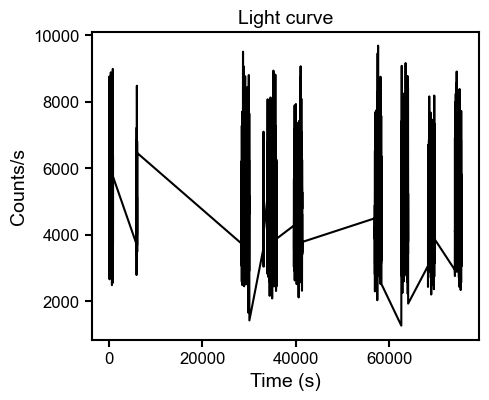

In [44]:
plt.figure(figsize=(5, 4))
plt.plot(time0, rate0,'-k')
plt.title("Light curve")
plt.xlabel(f"Time (s)")
plt.ylabel(f"Counts/s")
plt.legend()

0.02386436848561872
(126,)
12358 12358
103.43186210913711


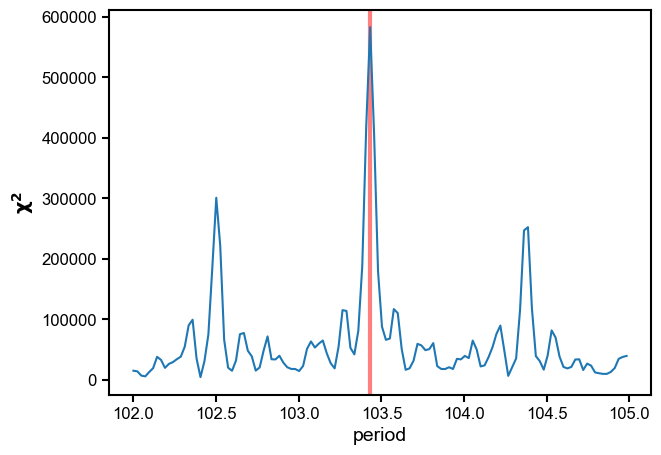

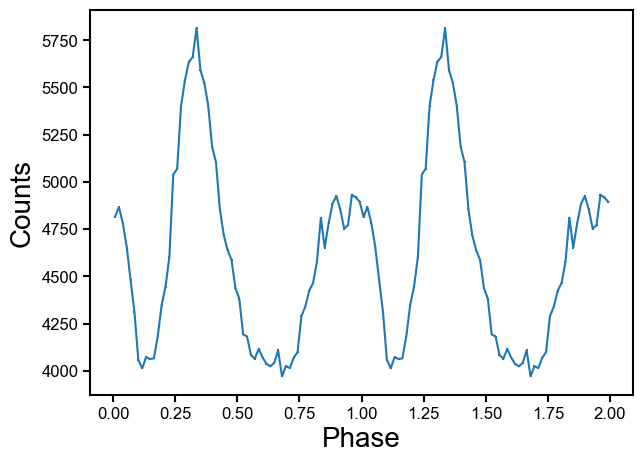

0.18826849168611368


In [45]:
###DO THIS ONLY FOR PULSARS###
###HOW to subtract pulse from lcurve?###

#step 1: searching for the spin period:
#how to choose the resolution?
dp = 104**2/(t.max()-t.min())/2./3.
#dp = 1e-5
print(dp)
prange = np.arange(102, 105, dp) #explain why
print(prange.shape)


# efolding method, an example for binned data
print(len(t),len(rate0))
prange, chi2 = efold_search(t, rate0, prange, ref=0, cts_err = error0, nbins = 16, dt = 1)
period = prange[np.argmax(chi2)]
print(period)
plt.errorbar(prange, chi2)
plt.xlabel('period')
plt.ylabel('$\mathbf{\chi^2}$')
plt.axvline(period, lw=3, alpha=0.5, color='r', label='Correct frequency')
plt.show()

#step 2: fold the light curve to pulse profile
phase_bins, profile, profile_err=efold(t, rate0, period, nbins = 64, dt = 1, cts_err = error0)
plt.errorbar(np.hstack([phase_bins, phase_bins +1]), np.hstack([profile, profile]),\
             yerr = np.hstack([profile_err, profile_err]),fmt = '-')
plt.xlabel('Phase', fontsize = 20)
plt.ylabel('Counts', fontsize = 20)
plt.show()
rms=(profile.max()-profile.min())/(profile.max()+profile.min())
print(rms)

In [46]:
#step 3: Use interpolated to build a continuous function of the pulse profile 

# 假设你有一些观测值
x_observed = phase_bins
y_observed = profile

# 使用观测值创建三次样条插值对象
cubic_spline = CubicSpline(x_observed, y_observed)

#step 4: get the count rate at any phase

phase = STpulse.pulse_phase(t, 1./period)
# 获取任意 x 位置点的 y 值
x_position = phase
y_interpolated = cubic_spline(x_position)

#step 4: subtract pulse from light curve:
rate_unpulse=rate0-y_interpolated
lc_unpulse = Lightcurve(time0, rate_unpulse, dt = dt, input_counts=False)

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_imfs_vmd(t, imfs, lc, long):
    N_c = len(imfs)
    
    # 创建子图，N_c+1 行 1 列，共享 X 轴
    fig, axes = plt.subplots(N_c + 1, 1, figsize=(5, 5), sharex=True)
    
    # 初始化数据存储
    data_dict = {'Time': t[:long], 'C0': lc[:long]}
    
    # 绘制原始信号
    axes[0].plot(t[:long], lc[:long], color='k')
    axes[0].set_ylabel('Pulse\n subtracted\n Signal')
    
    # 绘制各个 IMF 分量
    for i in range(1, N_c + 1):
        if i == 1:
            color = 'blue'
        elif i == 2:
            color = 'red'
        else:
            color = 'green'
        
        axes[i].plot(t[:long], imfs[i - 1, :long], color=color)
        if i == 3:
            axes[i].set_ylabel(f'IMF{i}-{N_c+i-1}')
        else:
            axes[i].set_ylabel(f'IMF{i}')
        
        # 保存数据到字典
        data_dict[f'C{i}'] = imfs[i - 1, :long]
    
    # 设置 X 轴标签
    axes[-1].set_xlabel('Time (s)')
    
    # 调整布局
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    # 保存图像
    plt.savefig('IMFs.pdf')
    
    # 创建并保存 DataFrame
    df = pd.DataFrame(data_dict)
    df.to_csv('imfs_data.csv', index=False)


(5, 12358)
(3, 12358)


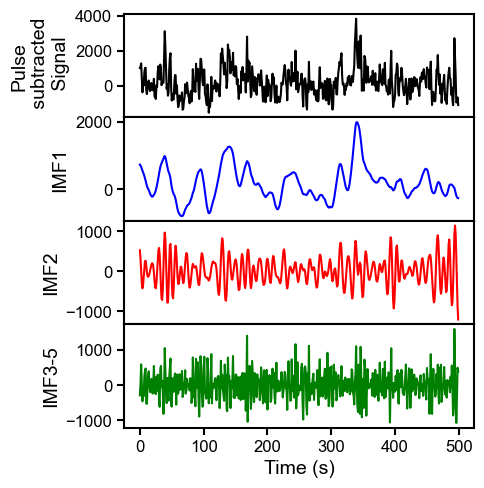

In [54]:
from sktime.transformations.series.vmd import VmdTransformer  
transformer = VmdTransformer(alpha=100,K=5)
imfs = transformer.fit_transform(rate_unpulse)  
imfs = imfs.T
print(imfs.shape)
lc_comps = np.array([imfs[0],imfs[1],(imfs[2]+imfs[3]+imfs[4])])
#lc_comps = np.array([imfs[0],imfs[1],(imfs[2]+imfs[3]+imfs[4]+imfs[5]+imfs[6])])
print(lc_comps.shape)
#plot_imfs_vmd(time0, lc_comps, rate0,500)
plot_imfs_vmd(time0, lc_comps, rate_unpulse,500)

19it [00:00, 16699.87it/s]
24it [00:00, 25317.73it/s]
19it [00:00, 13389.08it/s]
24it [00:00, 7938.75it/s]
19it [00:00, 9000.65it/s]
24it [00:00, 9635.62it/s]
24it [00:00, 16472.48it/s]
24it [00:00, 17178.04it/s]
24it [00:00, 19734.03it/s]
24it [00:00, 7183.56it/s]
24it [00:00, 12718.04it/s]
24it [00:00, 18575.99it/s]


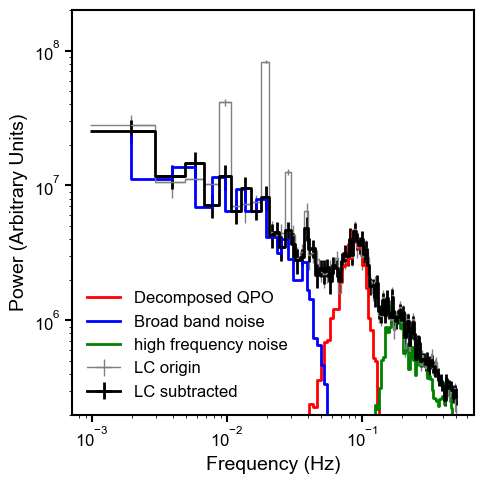

In [55]:
K=len(imfs)
num = K
N=K-1
nlong=512
# print(len(time0),len(imfs[num - N]))
lc_decomp = Lightcurve(time0, lc_comps[1], dt = dt)
lc_decomp1 = Lightcurve(time0, lc_comps[0], dt = dt)
lc_decomp2 = Lightcurve(time0, lc_comps[2], dt = dt)


#plot_pds(lc_new, lc_decomp,256)
ps_total0, ps_decomp_0=plot_pds(lc_new, lc_decomp,nlong,'abs')
ps_total0, ps_decomp1_0=plot_pds(lc_new, lc_decomp1,nlong,'abs')
ps_total0, ps_decomp2_0=plot_pds(lc_new, lc_decomp2,nlong,'abs')

ps_total, ps_decomp=plot_pds(lc_unpulse, lc_decomp,nlong,'abs')
ps_total, ps_decomp1=plot_pds(lc_unpulse, lc_decomp1,nlong,'abs')
ps_total, ps_decomp2=plot_pds(lc_unpulse, lc_decomp2,nlong,'abs')


fig, axs = plt.subplots(1,1,figsize=(5, 5))
axs.errorbar(ps_total0.freq, ps_total0.power, xerr = ps_total.freq[0]/2., 
             yerr = ps_total.power_err, color = 'gray', fmt = '-',lw=1, ms = 0, drawstyle='steps-mid',label='LC origin')
axs.errorbar(ps_total.freq, ps_total.power, xerr = ps_total.freq[0]/2., 
             yerr = ps_total.power_err, color = 'k', fmt = '-',lw=2, ms = 0, drawstyle='steps-mid', label='LC subtracted')
axs.step(ps_decomp.freq, ps_decomp.power,color='red',lw=2, label='Decomposed QPO')
axs.step(ps_decomp.freq, ps_decomp1.power, color='blue',lw=2, label='Broad band noise')
axs.step(ps_decomp.freq, ps_decomp2.power, color='green',lw=2, label='high frequency noise')
#axs.set_xlabel('Frequency (Hz)')
axs.set_ylim(np.min(ps_total.power),np.max(ps_total.power))
axs.set_ylim(2e5,2e8)
axs.set_xscale('log')
axs.set_yscale('log')
plt.legend()
# axs.set_xlabel('Frequency (Hz)',fontsize=14, fontweight='bold',fontname='Times New Roman')
# axs.set_ylabel('Power (Arbitrary Units)',fontsize=14, fontweight='bold',fontname='Times New Roman')
axs.set_xlabel('Frequency (Hz)')
axs.set_ylabel('Power (Arbitrary Units)')
# for spine in ['top', 'right', 'bottom', 'left']:  
#     axs.spines[spine].set_linewidth(1)
#axs.tick_params(axis='x', which='both',color='black',direction='in')
#axs.set_title('Date: 2020-11-20', fontsize=14, fontweight='bold',fontname='Times New Roman') 
#axs.tick_params(axis='both', which='major', length=3, width=1, color='black') 
plt.tight_layout()
plt.savefig("QPO_decomposed_20201120.pdf")
df_ps=pd.DataFrame({
    'Frequency': ps_total0.freq,
    'Frequency_Error': ps_total0.freq[0]/2.,
    'Power1': ps_total0.power,
    'Power1_Error': ps_total0.power_err,
    'Power2': ps_total.power,
    'Power2_Error': ps_total.power_err,
    'Power3': ps_decomp.power,
    'Power4': ps_decomp1.power,
})
df_ps.to_csv('ps.csv', index=False)

In [56]:
sample_rate=len(time0)/(exposure)
IP, IF, IA = emd.spectra.frequency_transform(imfs.T,sample_rate, 'nht')

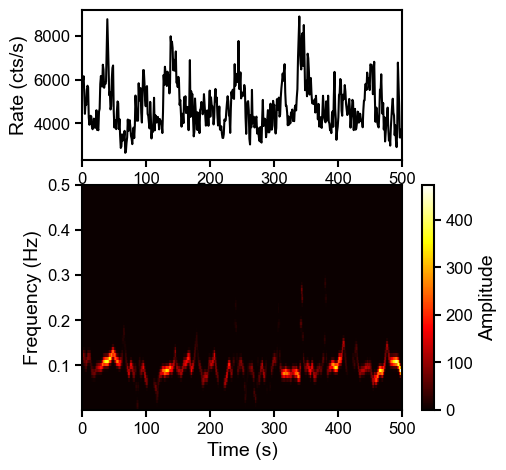

In [72]:
##### Carrier frequency histogram definition
long=500
freq_edges, freq_centres = emd.spectra.define_hist_bins(1/512, 0.5, 24*3, 'linear')
f, hht = emd.spectra.hilberthuang(IF[:,num-N], IA[:, num-N], freq_edges, mode='amplitude', sum_time=False)
#f, hht = emd.spectra.hilberthuang(IF[:,2], IA[:,2], freq_edges, mode='amplitude', sum_time=False)
hht = ndimage.gaussian_filter(hht, 1)
time_centres = np.arange(long+1)-.5
plt.figure(figsize=(5,5))
# Add signal and IA
plt.axes([.1, .6, .64, .3])
#plt.plot(time0[:long],imfs.T[:long, num-N], 'k')
plt.plot(time0[:long],rate0[:long], 'k')
#plt.yscale('log')
plt.ylabel('Rate (cts/s)')
#plt.plot(time0[:long],imfs.T[:long, num-N-1], 'g')
#plt.plot(IA[:, num-N], 'r')
#plt.legend(['IMF', 'IF'])
plt.xlim(0, long)
#plt.ylim(-50,50)

# Add IF axis and legend
plt.axes([.1, .1, .8, .45])

# Plot HHT
# print(hht[:, :long].shape)
# print(time0[:long].shape)
plt.pcolormesh(time0[:long+1], freq_edges, hht[:, :long], cmap='hot', vmin=0)

# Set colourbar
cb = plt.colorbar()
cb.set_label('Amplitude', rotation=90)

# Set lims and labels
#plt.xlim(0, long)
plt.ylim(1/nlong, 0.5)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
#plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('HHT.pdf')

In [77]:
#f=np.mean(IF[:,num-N])
f=np.mean(IF[:,2])
print(f)
print(1/f)

0.17976109256516826
5.562939041647585


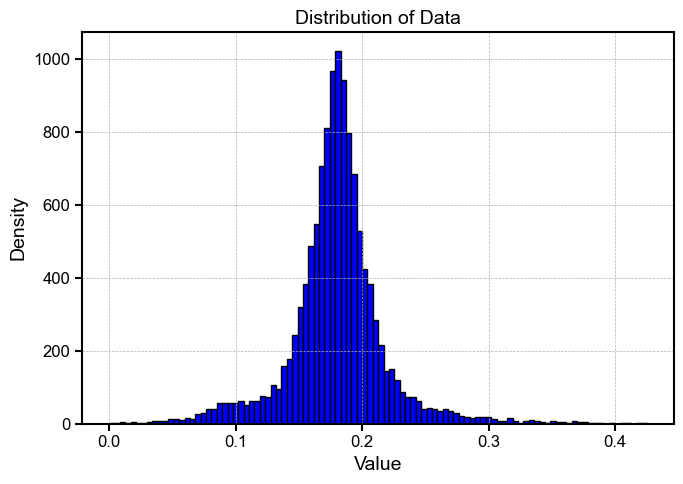

In [81]:
# plt.figure(figsize=(6, 4))
#plt.hist(IF[:,num-N], bins=100, color='blue', edgecolor='black')
plt.hist(IF[:,2], bins=100, color='blue', edgecolor='black')

# 添加标题和轴标签
plt.title('Distribution of Data')
plt.xlabel('Value')
plt.ylabel('Density')

# 显示网格
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
#plt.xlim(0.002,0.15)
# 显示图形
plt.tight_layout()
plt.show()

In [85]:
#Reimf = hilbert(imfs[num - N])
Reimf = hilbert(imfs[2])

phase = np.angle(Reimf)
normalized_phase = (phase + np.pi) / (2 * np.pi)
normalized_phase = np.mod(normalized_phase, 1.0)
print(len(normalized_phase),len(rate0))

12358 12358


In [86]:
phase_bins, profile

(array([0.0078125, 0.0234375, 0.0390625, 0.0546875, 0.0703125, 0.0859375,
        0.1015625, 0.1171875, 0.1328125, 0.1484375, 0.1640625, 0.1796875,
        0.1953125, 0.2109375, 0.2265625, 0.2421875, 0.2578125, 0.2734375,
        0.2890625, 0.3046875, 0.3203125, 0.3359375, 0.3515625, 0.3671875,
        0.3828125, 0.3984375, 0.4140625, 0.4296875, 0.4453125, 0.4609375,
        0.4765625, 0.4921875, 0.5078125, 0.5234375, 0.5390625, 0.5546875,
        0.5703125, 0.5859375, 0.6015625, 0.6171875, 0.6328125, 0.6484375,
        0.6640625, 0.6796875, 0.6953125, 0.7109375, 0.7265625, 0.7421875,
        0.7578125, 0.7734375, 0.7890625, 0.8046875, 0.8203125, 0.8359375,
        0.8515625, 0.8671875, 0.8828125, 0.8984375, 0.9140625, 0.9296875,
        0.9453125, 0.9609375, 0.9765625, 0.9921875]),
 array([4815.0107868 , 4866.70153061, 4782.20384615, 4658.34311224,
        4481.97239848, 4312.1875    , 4058.82844388, 4013.27706186,
        4072.45304569, 4062.28108808, 4065.87890625, 4181.64935897,
  

In [92]:
#####make GTI files from QPO phases#####
phase_edge=[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in phase_edge:
    target_phase_start = round(i, 1)
    target_phase_end = round(i+0.1, 1)
    print(target_phase_start,target_phase_end)
    time_points=(normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
    GTI_low = np.around(t[time_points] - dt/2., 5)
    GTI_high = np.around(t[time_points] + dt/2., 5)
    GTI_pre = np.vstack((list(GTI_low), list(GTI_high)))
    GTI_pre = GTI_pre.T
    GTI = combine_gti_continuous(GTI_pre)
    GTI=np.array(GTI)
    GTI[0][0],GTI[0][1]
    np.savetxt('gti_tmp_%s_%s_%s_IMF2.txt'%(obsid,target_phase_start,target_phase_end), GTI)
    write_gti_fits(GTI,target_phase_start,target_phase_end)

0.0 0.1
len(wgti)= 1259
wgti[0][0],wgti[0][1] 280463149.5 280463150.5
len(x)= 1255
0.1 0.2
len(wgti)= 1253
wgti[0][0],wgti[0][1] 280463150.5 280463151.5
len(x)= 1244
0.2 0.3
len(wgti)= 1224
wgti[0][0],wgti[0][1] 280463145.5 280463146.5
len(x)= 1212
0.3 0.4
len(wgti)= 1224
wgti[0][0],wgti[0][1] 280463151.5 280463152.5
len(x)= 1213
0.4 0.5
len(wgti)= 1244
wgti[0][0],wgti[0][1] 280463146.5 280463147.5
len(x)= 1232
0.5 0.6
len(wgti)= 1238
wgti[0][0],wgti[0][1] 280463152.5 280463153.5
len(x)= 1234
0.6 0.7
len(wgti)= 1214
wgti[0][0],wgti[0][1] 280463147.5 280463148.5
len(x)= 1204
0.7 0.8
len(wgti)= 1232
wgti[0][0],wgti[0][1] 280463159.5 280463160.5
len(x)= 1226
0.8 0.9
len(wgti)= 1257
wgti[0][0],wgti[0][1] 280463148.5 280463149.5
len(x)= 1248
0.9 1.0
len(wgti)= 1213
wgti[0][0],wgti[0][1] 280463144.5 280463145.5
len(x)= 1206


In [90]:
print("Obsid:", obsid)
# print("Average Freq:", np.mean(IF[:,num-N]), "Hz")
print("Average Freq:", np.mean(IF[:,2]), "Hz")
print("Average Rate:", np.mean(rate0), "cts/s")
print("Total exposure:", exposure)

Obsid: 20201120
Average Freq: 0.17976109256516826 Hz
Average Rate: 4603.034 cts/s
Total exposure: 12356.0


[(0.0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.0)]


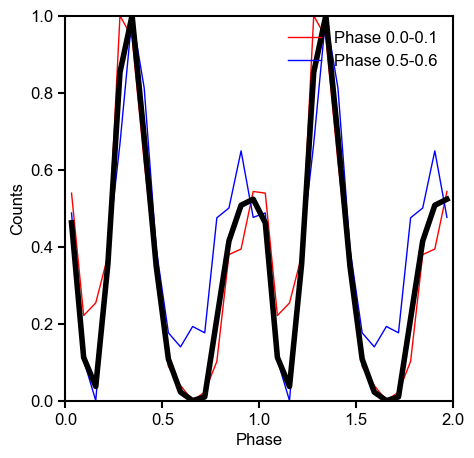

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# 假设已有 normalized_phase, t, rate0, error0, STpulse.pulse_phase, efold 等必要数据和函数
target_phases = [(i/10, (i+1)/10) for i in range(10)]  # 生成十个相位区间
#target_phases=[(0.0,0.1),(0.5,0.6)]
print(target_phases)
nbins = 16

# 预设颜色循环器
colors = cycle(plt.cm.tab10(np.linspace(0, 1, 10)))  # 使用Tab10调色板生成不同颜色

# 创建画布
plt.figure(figsize=(5, 5)) 
rate=rate0
error=error0
for i, (target_phase_start, target_phase_end) in enumerate(target_phases):
    #print(target_phase_start, target_phase_end)
    time_points = (normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
    t_QPO = t[time_points]
    rate_QPO = rate[time_points]
    error_QPO = error[time_points]
    
    # 计算自旋相位
    spinphase_QPO = STpulse.pulse_phase(t_QPO, 1. / period)
    
    # 折叠光变曲线
    phase_bins_QPOphase, profile_QPOphase, profile_QPOphase_err = efold(t_QPO, rate_QPO, period, nbins=16, dt=1, cts_err=error_QPO)
    profile_QPOphase=(profile_QPOphase-np.min(profile_QPOphase))/(np.max(profile_QPOphase)-np.min(profile_QPOphase))
    #profile_QPOphase_err=profile_QPOphase_err/np.mean(profile_QPOphase)
    #profile_QPOphase=profile_QPOphase/np.mean(profile_QPOphase)
    # 在同一张图上绘制，使用不同颜色
    # plt.errorbar(np.hstack([phase_bins_QPOphase, phase_bins_QPOphase + 1]), 
    #              np.hstack([profile_QPOphase, profile_QPOphase]), 
    #              fmt='-', lw=1, label=f'Phase {target_phase_start:.1f}-{target_phase_end:.1f}', color=next(colors))
    # plt.errorbar(np.hstack([phase_bins_QPOphase, phase_bins_QPOphase + 1]), 
    #             np.hstack([profile_QPOphase, profile_QPOphase]), 
    #             #yerr=np.hstack([profile_QPOphase_err,profile_QPOphase_err]),
    #             fmt='-', lw=1, color='gray')
    if target_phase_start==0.0 and target_phase_end == 0.1:
        plt.errorbar(np.hstack([phase_bins_QPOphase, phase_bins_QPOphase + 1]), 
                     np.hstack([profile_QPOphase, profile_QPOphase]),
                     #yerr=np.hstack([profile_QPOphase_err,profile_QPOphase_err]),
                     fmt='-', lw=1, label=f'Phase {target_phase_start:.1f}-{target_phase_end:.1f}', color='red')
    if target_phase_start==0.5 and target_phase_end == 0.6:
        plt.errorbar(np.hstack([phase_bins_QPOphase, phase_bins_QPOphase + 1]), 
                     np.hstack([profile_QPOphase, profile_QPOphase]), 
                     #yerr=np.hstack([profile_QPOphase_err,profile_QPOphase_err]),
                     fmt='-', lw=1, label=f'Phase {target_phase_start:.1f}-{target_phase_end:.1f}', color='blue')
    
# target_phase_start = 0.0
# target_phase_end = 1.0
# #print(target_phase_start,target_phase_end)
# time_points=(normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
# t_QPO=t[time_points]
# rate_QPO=rate0[time_points]
# error_QPO=error0[time_points]
# spinphase_QPO = STpulse.pulse_phase(t_QPO, 1./period) 
phase_bins_QPOphase, profile_QPOphase, profile_QPOphase_err=efold(t, rate, period, nbins = 16, dt = 1, cts_err = error0)
profile_QPOphase=(profile_QPOphase-np.min(profile_QPOphase))/(np.max(profile_QPOphase)-np.min(profile_QPOphase))
#print(profile_QPOphase_err,profile_QPOphase)
#profile_QPOphase_err=profile_QPOphase_err/np.mean(profile_QPOphase)
#profile_QPOphase=profile_QPOphase/np.mean(profile_QPOphase)
plt.errorbar(np.hstack([phase_bins_QPOphase, phase_bins_QPOphase +1]), np.hstack([profile_QPOphase, profile_QPOphase]),
             #yerr=np.hstack([profile_QPOphase_err,profile_QPOphase_err]),
             fmt = '-',lw=4,color='black')
# 设置图表标题和标签
plt.xlabel('Phase', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.xlim(0.0,2.0)
plt.ylim(0.0,1.0)
plt.legend(loc='upper right')
#plt.title('a) QPO phase-resolved pulse profiles\n Nov 20, 2020', fontsize=14)
#plt.title('25-80 keV')
plt.savefig('fold_lc_QPOphases_1120_25_80.pdf')
plt.show()
# # 假设你的数据是以下列表
# # 创建DataFrame
# df = pd.DataFrame({'x': phase_bins_QPOphase, 'y': profile_QPOphase, 'y_err': profile_QPOphase_err})

# # 保存为CSV文件
# df.to_csv('pulse_profile.csv', index=False)

# print("CSV 文件已保存为 data.csv")

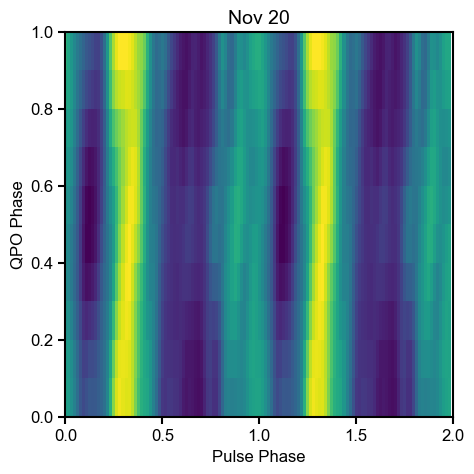

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 假设已有 normalized_phase, t, rate0, error0, STpulse.pulse_phase, efold 等必要数据和函数
target_phases = [(i/10, (i+1)/10) for i in range(10)]  # 生成十个相位区间
nbins = 64

# 存储每个QPO相位区间的脉冲轮廓
profiles = []
qpo_midpoints = []

# 计算全局平均脉冲轮廓作为参考
_, profile_QPOphase, _ = efold(t, rate, period, nbins=16, dt=1, cts_err=error0)
global_mean = np.mean(profile_QPOphase)
global_mean=np.hstack([global_mean, global_mean])

for i, (target_phase_start, target_phase_end) in enumerate(target_phases):
    qpo_midpoints.append((target_phase_start + target_phase_end) / 2)
    
    time_points = (normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
    t_QPO = t[time_points]
    rate_QPO = rate[time_points]
    error_QPO = error[time_points]
    
    spinphase_QPO = STpulse.pulse_phase(t_QPO, 1. / period)
    
    # 折叠光变曲线
    phase_bins, profile_bins, _ = efold(t_QPO, rate_QPO, period, nbins=nbins, dt=1, cts_err=error_QPO)
    
    # 归一化：减去最小值并除以幅度
    min_val = np.min(profile_bins)
    max_val = np.max(profile_bins)
    normalized_profile = (profile_bins - min_val) / (max_val - min_val) if (max_val - min_val) > 0 else profile_bins
    #normalized_profile = profile_bins/np.mean(profile_bins)
    normalized_profile = np.hstack([normalized_profile, normalized_profile])
    # 相对于全局平均归一化
    #normalized_profile = profile_bins / global_mean
    
    profiles.append(normalized_profile)

# 转换为二维数组
pulse_phase_bins = np.linspace(0, 2, 2*nbins, endpoint=False)
#pulse_phase_bins = 
qpo_phase_grid, pulse_phase_grid = np.meshgrid(qpo_midpoints, pulse_phase_bins)
profile_grid = np.array(profiles).T  # 转置使行对应脉冲相位，列对应QPO相位

# 创建二维图
plt.figure(figsize=(5, 5))
cmap = plt.cm.viridis  # 使用viridis颜色映射

# 绘制二维颜色图
from scipy.ndimage import gaussian_filter

# 对数据进行高斯滤波（sigma 控制平滑程度）
smoothed_data = gaussian_filter(profile_grid, sigma=1)
im = plt.pcolormesh(pulse_phase_grid, qpo_phase_grid, smoothed_data, 
                   shading='auto', cmap=cmap)
#plt.colorbar(im, label='Normalized Pulse Profile Intensity')

# 设置坐标轴标签
plt.xlabel('Pulse Phase', fontsize=12)
plt.ylabel('QPO Phase', fontsize=12)
#plt.title('25-80 keV', fontsize=14)
plt.title('Nov 20')
# 添加网格线
#plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0,2)
# plt.tight_layout()
plt.savefig('fold_lc_QPO2Dphases_1120_25_80.pdf')
plt.show()

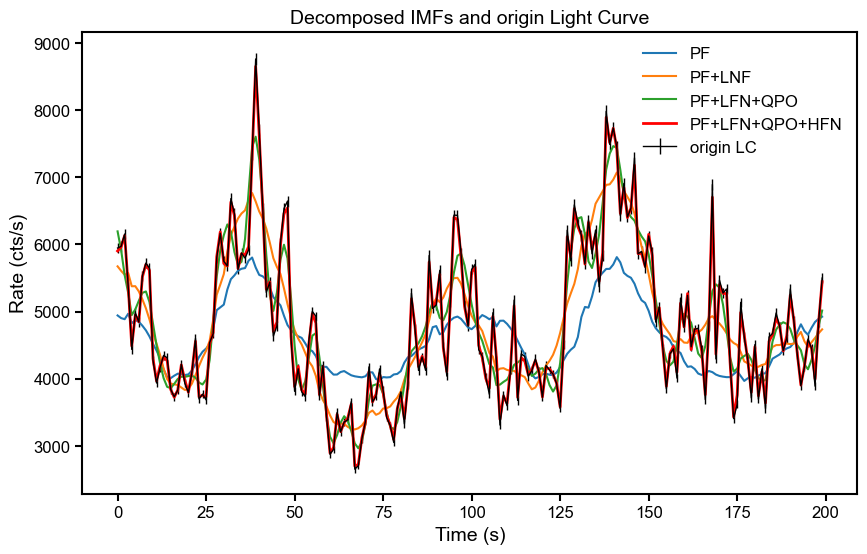

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
long=200
ax.errorbar(time0[:long],rate0[:long],error0[:long],fmt='-',color='black',lw=1,label="origin LC")
ax.plot(time0[:long],y_interpolated[:long],label="PF")
ax.plot(time0[:long],imfs[0][:long]+y_interpolated[:long],label="PF+LNF")
ax.plot(time0[:long],imfs[1][:long]+imfs[0][:long]+y_interpolated[:long],label="PF+LFN+QPO")
ax.plot(time0[:long],imfs[1][:long]+imfs[0][:long]+y_interpolated[:long]+np.sum(imfs[2:],axis=0)[:long],
         lw=2,color='red',label="PF+LFN+QPO+HFN")
#ax.legend(loc='lower left')
ax.set_ylabel('Rate (cts/s)')
ax.set_xlabel('Time (s)')
ax.legend()
plt.title('Decomposed IMFs and origin Light Curve', fontsize=14)
plt.savefig('IMF_fit_LC.pdf')
# #from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# long1 = 50
# # 添加小图（插图）
# ax_inset = fig.add_axes([0.35, 0.6, 0.25, 0.25])
# #ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right')  # 定义小图大小和位置
# ax_inset.errorbar(time0[:long1],rate0[:long1],error0[:long1],fmt='-',color='black',lw=1,label="origin LC")
# ax_inset.plot(time0[:long1],y_interpolated[:long1],label="PF")
# ax_inset.plot(time0[:long1],imfs[0][:long1]+y_interpolated[:long1],label="PF+LNF")
# ax_inset.plot(time0[:long1],imfs[1][:long1]+imfs[0][:long1]+y_interpolated[:long1],label="PF+LFN+QPO")
# ax_inset.plot(time0[:long1],imfs[1][:long1]+imfs[0][:long1]+y_interpolated[:long1]+np.sum(imfs[2:],axis=0)[:long1],
#          lw=2,color='red',label="PF+LFN+QPO+HFN")
# ax_inset.set_xticks([])
# ax_inset.set_yticks([])


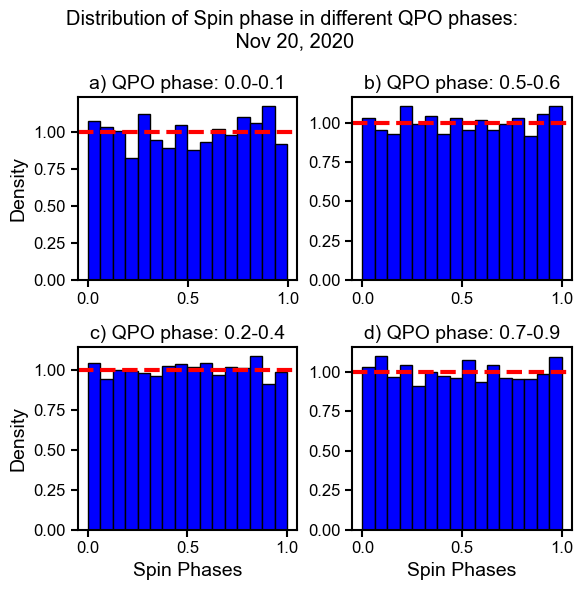

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(6, 6))

target_phase_start = 0.0
target_phase_end = 0.1
time_points=(normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
t_QPO=t[time_points]
spinphase_QPO = STpulse.pulse_phase(t_QPO, 1./period) 
axs[0,0].hist(spinphase_QPO, bins=16, color='blue', edgecolor='black',density=True)
axs[0,0].set_title('a) QPO phase: %s-%s'%(target_phase_start,target_phase_end))
axs[0,0].axhline(y=1, color='r', linestyle='--',lw=3)

target_phase_start = 0.5
target_phase_end = 0.6
time_points=(normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
t_QPO=t[time_points]
spinphase_QPO = STpulse.pulse_phase(t_QPO, 1./period) 
axs[0,1].hist(spinphase_QPO, bins=16, color='blue', edgecolor='black',density=True)
axs[0,1].set_title('b) QPO phase: %s-%s'%(target_phase_start,target_phase_end))
axs[0,1].axhline(y=1, color='r', linestyle='--',lw=3)

target_phase_start = 0.2
target_phase_end = 0.4
time_points=(normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
t_QPO=t[time_points]
spinphase_QPO = STpulse.pulse_phase(t_QPO, 1./period) 
axs[1,0].hist(spinphase_QPO, bins=16, color='blue', edgecolor='black',density=True)
axs[1,0].set_title('c) QPO phase: %s-%s'%(target_phase_start,target_phase_end))
axs[1,0].axhline(y=1, color='r', linestyle='--',lw=3)

target_phase_start = 0.7
target_phase_end = 0.9
time_points=(normalized_phase >= target_phase_start) & (normalized_phase <= target_phase_end)
t_QPO=t[time_points]
spinphase_QPO = STpulse.pulse_phase(t_QPO, 1./period) 
axs[1,1].hist(spinphase_QPO, bins=16, color='blue', edgecolor='black',density=True)
axs[1,1].set_title('d) QPO phase: %s-%s'%(target_phase_start,target_phase_end))
axs[1,1].axhline(y=1, color='r', linestyle='--',lw=3)

axs[1,0].set_xlabel('Spin Phases')
axs[1,1].set_xlabel('Spin Phases')
axs[0,0].set_ylabel('Density')
axs[1,0].set_ylabel('Density')
# 显示网格
#axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
#axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
# 显示图形
fig.suptitle('Distribution of Spin phase in different QPO phases:\n Nov 20, 2020')
plt.tight_layout()
plt.savefig('Distribution_1120.pdf')
plt.show()